## German to English Translation Guide

This notebook analyzes Swiss cybercrime data with German column names. Here's the translation reference:

### Column Names (Deutsch → English):
- **Ausgangsjahr** → Year
- **CyberModus_Überkategorie** → Crime Category (High-level)
- **CyberModus_Unterkategorie** → Crime Type (Detailed)
- **Straftaten_total** → Total Offenses
- **Straftaten_vollendet** → Completed Offenses
- **Straftaten_versucht** → Attempted Offenses
- **Einwohner** → Population
- **Häufigkeitszahl** → Crime Rate (per 100,000 inhabitants)

### Main Crime Categories:
- **Cybercrime (im engeren Sinne)** → Cybercrime (narrow sense) - e.g., Phishing, Hacking, Malware, DoS/DDoS
- **digitalisierte Vermögenskriminalität** → Digitalized Property Crime - e.g., Cyberbetrug (fraud), Financial agents
- **Cyber-Sexualdelikte** → Cyber-Sexual Offenses
- **Cyber-Rufschädigung und unlauteres Verhalten** → Cyber-Defamation and Unfair Conduct


# Swiss Cybercrime Data Analysis

This notebook explores the Swiss digital crimes dataset to understand cybercrime trends and identify interesting visualizations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load the dataset
df = pd.read_csv('../Dataset/KTZH_00001202_00003680.csv')

print("Dataset shape:", df.shape)
print("\nColumn names and types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head(10)

Dataset shape: (93, 8)

Column names and types:
Ausgangsjahr                   int64
CyberModus_Überkategorie         str
CyberModus_Unterkategorie        str
Straftaten_total               int64
Straftaten_vollendet           int64
Straftaten_versucht            int64
Einwohner                      int64
Häufigkeitszahl              float64
dtype: object

First few rows:


,Ausgangsjahr,CyberModus_Überkategorie,CyberModus_Unterkategorie,Straftaten_total,Straftaten_vollendet,Straftaten_versucht,Einwohner,Häufigkeitszahl
0,2017,Cybercrime (im engeren Sinne),Phishing,336,275,61,1487969,0.2
1,2017,Cybercrime (im engeren Sinne),Hacking,151,133,18,1487969,0.1
2,2017,Cybercrime (im engeren Sinne),Malware,77,70,7,1487969,0.1
3,2017,Cybercrime (im engeren Sinne),DoS/DDoS,26,18,8,1487969,0.0
4,2017,digitalisierte Vermögenskriminalität,Cyberbetrug,1273,1132,141,1487969,0.9
5,2017,digitalisierte Vermögenskriminalität,Finanz- und Paketagenten,56,48,8,1487969,0.0
6,2017,digitalisierte Vermögenskriminalität,Sextortion (money),51,37,14,1487969,0.0
7,2017,Cyber-Sexualdelikte,Sexualdelikte,120,114,6,1487969,0.1
8,2017,Cyber-Rufschädigung und unlauteres Verhalten,Rufschädigung und unlauteres Verhalten,76,70,6,1487969,0.1
9,2018,Cybercrime (im engeren Sinne),Phishing,630,528,102,1504346,0.4


In [3]:
# Translate German columns and values to English
df.columns = ['Year', 'Crime_Category', 'Crime_Type', 'Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses', 'Population', 'Crime_Rate']

# Translation dictionary for crime categories
category_translation = {
    'Cybercrime (im engeren Sinne)': 'Cybercrime (Narrow Sense)',
    'digitalisierte Vermögenskriminalität': 'Digitalized Property Crime',
    'Cyber-Sexualdelikte': 'Cyber-Sexual Offenses',
    'Cyber-Rufschädigung und unlauteres Verhalten': 'Cyber-Defamation & Unfair Conduct'
}

# Translation dictionary for crime types
crime_type_translation = {
    'Phishing': 'Phishing',
    'Hacking': 'Hacking',
    'Malware': 'Malware',
    'DoS/DDoS': 'DoS/DDoS',
    'Cyberbetrug': 'Cyberbetrug (Fraud)',
    'Finanz- und Paketagenten': 'Financial & Parcel Agents',
    'Sextortion (money)': 'Sextortion (Money)',
    'Sexualdelikte': 'Sexual Offenses',
    'Rufschädigung und unlauteres Verhalten': 'Defamation & Unfair Conduct'
}

# Apply translations
df['Crime_Category'] = df['Crime_Category'].map(category_translation).fillna(df['Crime_Category'])
df['Crime_Type'] = df['Crime_Type'].map(crime_type_translation).fillna(df['Crime_Type'])

print("✓ Dataset translated to English")
print("\nTranslated columns:", df.columns.tolist())
print("\nFirst few rows with English labels:\"")
df.head(10)

✓ Dataset translated to English

Translated columns: ['Year', 'Crime_Category', 'Crime_Type', 'Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses', 'Population', 'Crime_Rate']

First few rows with English labels:"


,Year,Crime_Category,Crime_Type,Total_Offenses,Completed_Offenses,Attempted_Offenses,Population,Crime_Rate
0,2017,Cybercrime (Narrow Sense),Phishing,336,275,61,1487969,0.2
1,2017,Cybercrime (Narrow Sense),Hacking,151,133,18,1487969,0.1
2,2017,Cybercrime (Narrow Sense),Malware,77,70,7,1487969,0.1
3,2017,Cybercrime (Narrow Sense),DoS/DDoS,26,18,8,1487969,0.0
4,2017,Digitalized Property Crime,Cyberbetrug (Fraud),1273,1132,141,1487969,0.9
5,2017,Digitalized Property Crime,Financial & Parcel Agents,56,48,8,1487969,0.0
6,2017,Digitalized Property Crime,Sextortion (Money),51,37,14,1487969,0.0
7,2017,Cyber-Sexual Offenses,Sexual Offenses,120,114,6,1487969,0.1
8,2017,Cyber-Defamation & Unfair Conduct,Defamation & Unfair Conduct,76,70,6,1487969,0.1
9,2018,Cybercrime (Narrow Sense),Phishing,630,528,102,1504346,0.4


In [4]:
# Darknet and Data Leaking crimes (low-volume but emerging threats)
# Note: Darknet/Data Leaking entries appear only from 2023/2024 — very low volume but tracked

darknet_data = df[df['Crime_Type'] == 'Illegaler Handel im Darknet'].groupby('Year')[['Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses']].sum()
darknet_data.columns = ['Darknet_Total', 'Darknet_Completed', 'Darknet_Attempted']

data_leaking_data = df[df['Crime_Type'] == 'Data leaking'].groupby('Year')[['Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses']].sum()
data_leaking_data.columns = ['Data_Leaking_Total', 'Data_Leaking_Completed', 'Data_Leaking_Attempted']

# Reindex to full year range so gaps are visible
all_years = pd.DataFrame(index=sorted(df['Year'].unique()))
threats_df = all_years.join(darknet_data).join(data_leaking_data).fillna(0).astype(int)

print("Darknet & Data Leaking Crimes by Year:")
print(threats_df)
print(f"\nTotal Darknet Cases 2017–2024: {int(threats_df['Darknet_Total'].sum())}")
print(f"Total Data Leaking Cases 2017–2024: {int(threats_df['Data_Leaking_Total'].sum())}")


Darknet & Data Leaking Crimes by Year:
      Darknet_Total  Darknet_Completed  Darknet_Attempted  Data_Leaking_Total  \
2017              0                  0                  0                   0   
2018              0                  0                  0                   0   
2019              0                  0                  0                   0   
2020              0                  0                  0                   0   
2021              0                  0                  0                   0   
2022              0                  0                  0                   0   
2023              0                  0                  0                   0   
2024              0                  0                  0                   1   

      Data_Leaking_Completed  Data_Leaking_Attempted  
2017                       0                       0  
2018                       0                       0  
2019                       0                       0  
2020       

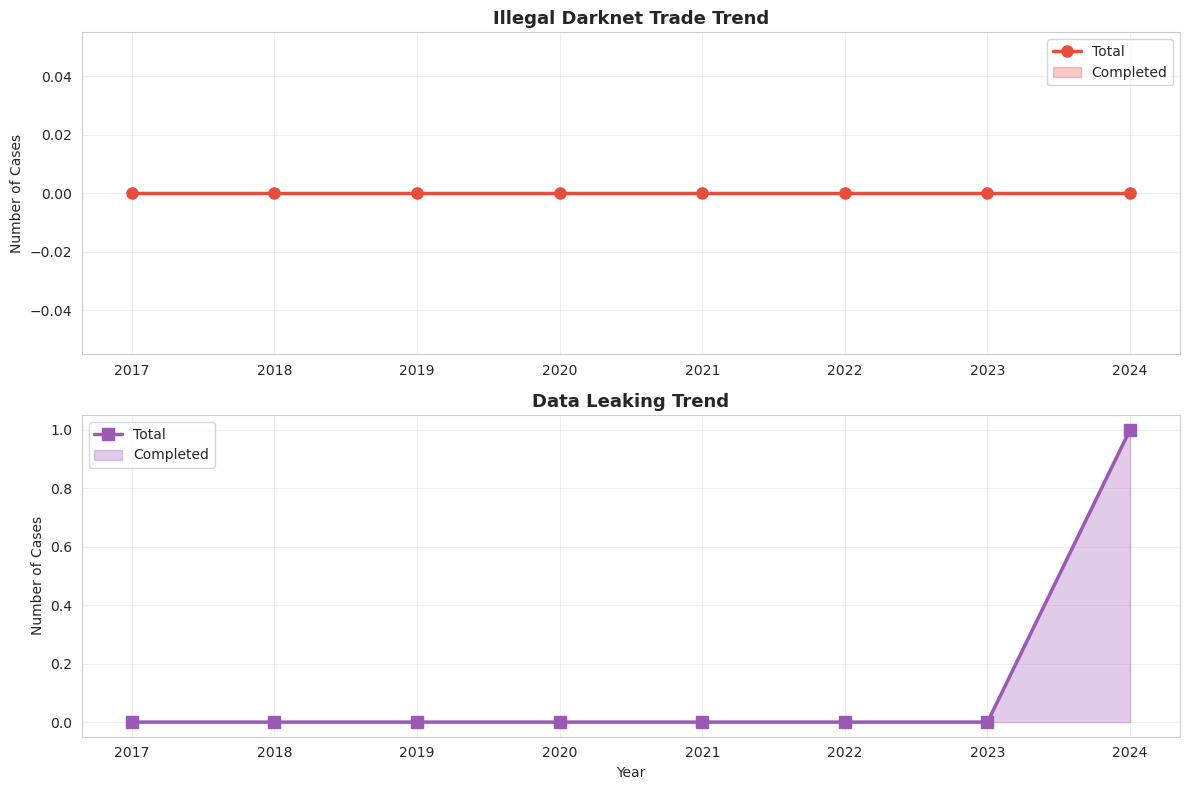

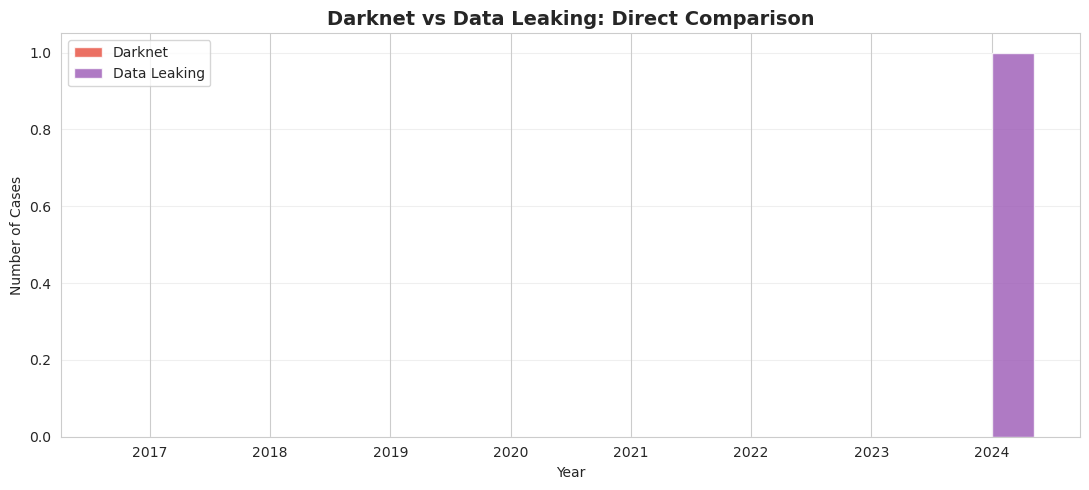

In [5]:
# Visualize Darknet vs Data Leaking trends
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Darknet trend
axes[0].plot(threats_df.index, threats_df['Darknet_Total'], marker='o', linewidth=2.5, markersize=8, color='#e74c3c', label='Total')
axes[0].fill_between(threats_df.index, threats_df['Darknet_Completed'], alpha=0.3, color='#e74c3c', label='Completed')
axes[0].set_title('Illegal Darknet Trade Trend', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Cases')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Data Leaking trend
axes[1].plot(threats_df.index, threats_df['Data_Leaking_Total'], marker='s', linewidth=2.5, markersize=8, color='#9b59b6', label='Total')
axes[1].fill_between(threats_df.index, threats_df['Data_Leaking_Completed'], alpha=0.3, color='#9b59b6', label='Completed')
axes[1].set_title('Data Leaking Trend', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Cases')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Side-by-side comparison
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(threats_df.index))
width = 0.35

ax.bar(x - width/2, threats_df['Darknet_Total'], width, label='Darknet', color='#e74c3c', alpha=0.8)
ax.bar(x + width/2, threats_df['Data_Leaking_Total'], width, label='Data Leaking', color='#9b59b6', alpha=0.8)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Cases')
ax.set_title('Darknet vs Data Leaking: Direct Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(threats_df.index)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [6]:
# Basic data exploration
print("Dataset Info:")
print(f"Total rows: {len(df)}")
print(f"Years covered: {sorted(df['Year'].unique())}")
print(f"\nNumber of crime categories (high-level): {df['Crime_Category'].nunique()}")
print(f"Number of crime types (detailed): {df['Crime_Type'].nunique()}")

print("\nCrime Categories:")
print(df['Crime_Category'].unique())

Dataset Info:
Total rows: 93
Years covered: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Number of crime categories (high-level): 5
Number of crime types (detailed): 12

Crime Categories:
<StringArray>
[        'Cybercrime (Narrow Sense)',        'Digitalized Property Crime',
             'Cyber-Sexual Offenses', 'Cyber-Defamation & Unfair Conduct',
              'Darknet/Data Leaking']
Length: 5, dtype: str


In [7]:
print("\nDetailed Crime Types:")
for category in df['Crime_Category'].unique():
    subtypes = df[df['Crime_Category'] == category]['Crime_Type'].unique()
    print(f"\n{category}:")
    for subtype in subtypes:
        print(f"  - {subtype}")


Detailed Crime Types:

Cybercrime (Narrow Sense):
  - Phishing
  - Hacking
  - Malware
  - DoS/DDoS

Digitalized Property Crime:
  - Cyberbetrug (Fraud)
  - Financial & Parcel Agents
  - Sextortion (Money)
  - Diebstahl Kryptowährungen

Cyber-Sexual Offenses:
  - Sexual Offenses

Cyber-Defamation & Unfair Conduct:
  - Defamation & Unfair Conduct

Darknet/Data Leaking:
  - Illegaler Handel im Darknet
  - Data leaking


In [8]:
# Statistical summary
print("\nStatistical Summary:")
print(df[['Total_Offenses', 'Completed_Offenses', 'Attempted_Offenses', 'Crime_Rate']].describe())


Statistical Summary:
       Total_Offenses  Completed_Offenses  Attempted_Offenses  Crime_Rate
count       93.000000           93.000000           93.000000   93.000000
mean       579.172043          534.236559           44.935484    0.372043
std       1492.779983         1409.808293           94.383446    0.941133
min          0.000000            0.000000            0.000000    0.000000
25%         17.000000           15.000000            1.000000    0.000000
50%        115.000000           93.000000           11.000000    0.100000
75%        410.000000          331.000000           31.000000    0.300000
max      10692.000000        10213.000000          479.000000    6.700000



Total Crimes by Year:
Year
2017     2166
2018     3580
2019     4201
2020     5673
2021     6898
2022     7465
2023     9718
2024    14162
Name: Total_Offenses, dtype: int64


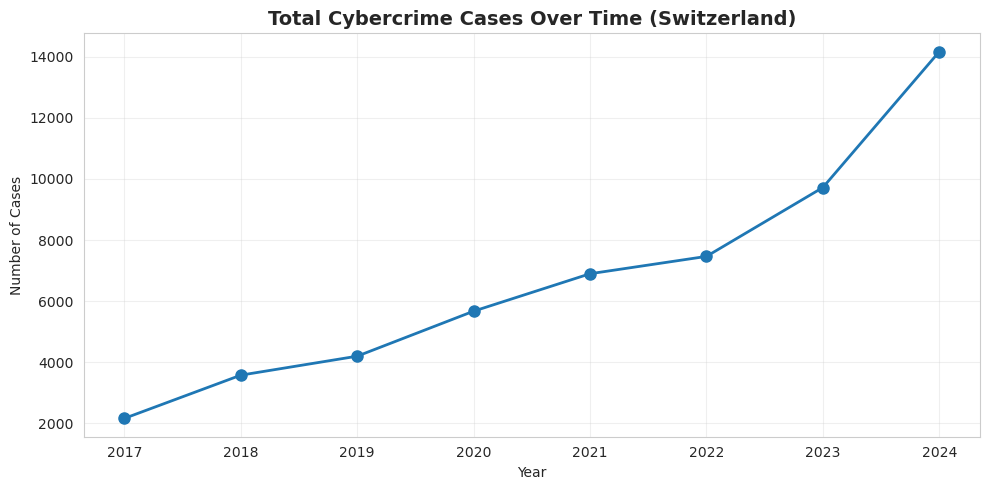

In [9]:
# Total crimes by year
crimes_by_year = df.groupby('Year')['Total_Offenses'].sum().sort_index()

print("\nTotal Crimes by Year:")
print(crimes_by_year)

# Plot trend
plt.figure(figsize=(10, 5))
plt.plot(crimes_by_year.index, crimes_by_year.values, marker='o', linewidth=2, markersize=8)
plt.title('Total Cybercrime Cases Over Time (Switzerland)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Completed vs Attempted Crimes by Year:
      Completed_Offenses  Attempted_Offenses
Year                                        
2017                1897                 269
2018                3088                 492
2019                3758                 443
2020                5154                 519
2021                6264                 634
2022                6890                 575
2023                9163                 555
2024               13470                 692


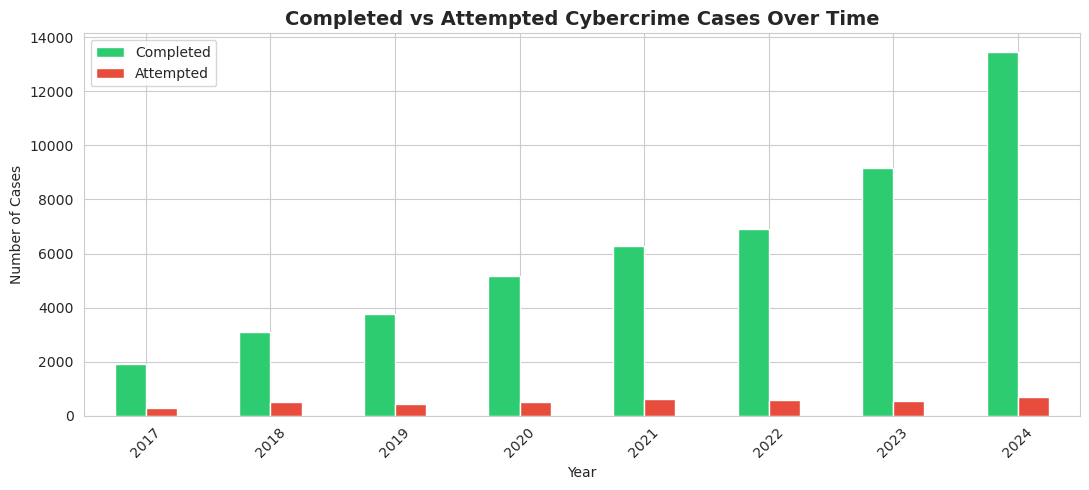

In [10]:
# Completed vs Attempted crimes
completion_by_year = df.groupby('Year')[['Completed_Offenses', 'Attempted_Offenses']].sum()

print("\nCompleted vs Attempted Crimes by Year:")
print(completion_by_year)

# Visualization
fig, ax = plt.subplots(figsize=(11, 5))
completion_by_year.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
plt.title('Completed vs Attempted Cybercrime Cases Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.legend(['Completed', 'Attempted'], loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Total Crimes by High-Level Category:
Crime_Category
Digitalized Property Crime           42368
Cybercrime (Narrow Sense)             6861
Cyber-Sexual Offenses                 3939
Cyber-Defamation & Unfair Conduct      694
Darknet/Data Leaking                     1
Name: Total_Offenses, dtype: int64


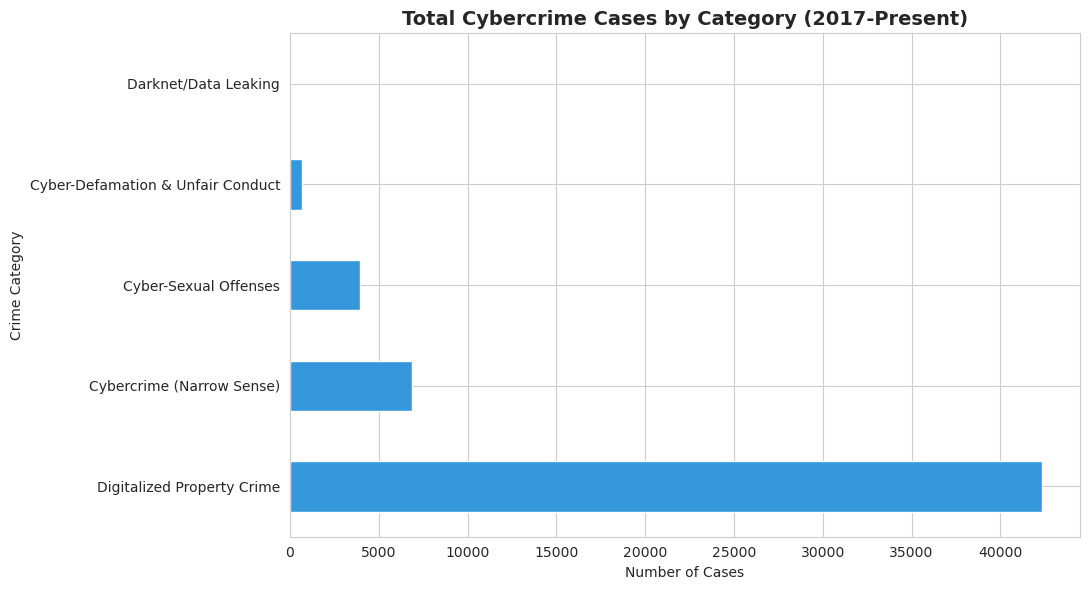

In [11]:
# Top crime categories overall
category_totals = df.groupby('Crime_Category')['Total_Offenses'].sum().sort_values(ascending=False)

print("\nTotal Crimes by High-Level Category:")
print(category_totals)

# Visualization
plt.figure(figsize=(11, 6))
category_totals.plot(kind='barh', color='#3498db')
plt.title('Total Cybercrime Cases by Category (2017-Present)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cases')
plt.ylabel('Crime Category')
plt.tight_layout()
plt.show()


Total Crimes by Detailed Type:
Crime_Type
Cyberbetrug (Fraud)            36126
Financial & Parcel Agents       4311
Sexual Offenses                 3939
Phishing                        3795
Hacking                         2077
Sextortion (Money)              1790
Malware                          880
Defamation & Unfair Conduct      694
Diebstahl Kryptowährungen        141
DoS/DDoS                         109
Data leaking                       1
Illegaler Handel im Darknet        0
Name: Total_Offenses, dtype: int64


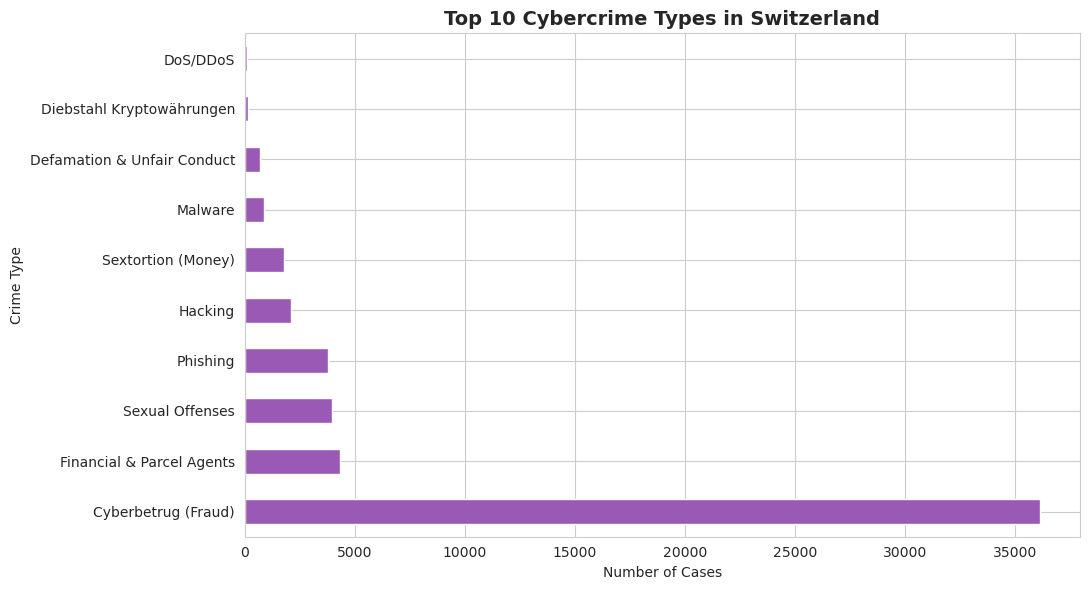

In [12]:
# Top crime types (subcategories)
subtype_totals = df.groupby('Crime_Type')['Total_Offenses'].sum().sort_values(ascending=False)

print("\nTotal Crimes by Detailed Type:")
print(subtype_totals)

# Visualization - top 10
plt.figure(figsize=(11, 6))
subtype_totals.head(10).plot(kind='barh', color='#9b59b6')
plt.title('Top 10 Cybercrime Types in Switzerland', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cases')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.show()


Category Trends Over Time:
Crime_Category  Cyber-Defamation & Unfair Conduct  Cyber-Sexual Offenses  \
Year                                                                       
2017                                         76.0                  120.0   
2018                                         82.0                  148.0   
2019                                        115.0                  587.0   
2020                                         91.0                  587.0   
2021                                         94.0                  578.0   
2022                                         93.0                  697.0   
2023                                         69.0                  573.0   
2024                                         74.0                  649.0   

Crime_Category  Cybercrime (Narrow Sense)  Darknet/Data Leaking  \
Year                                                              
2017                                590.0                   NaN   
2018      

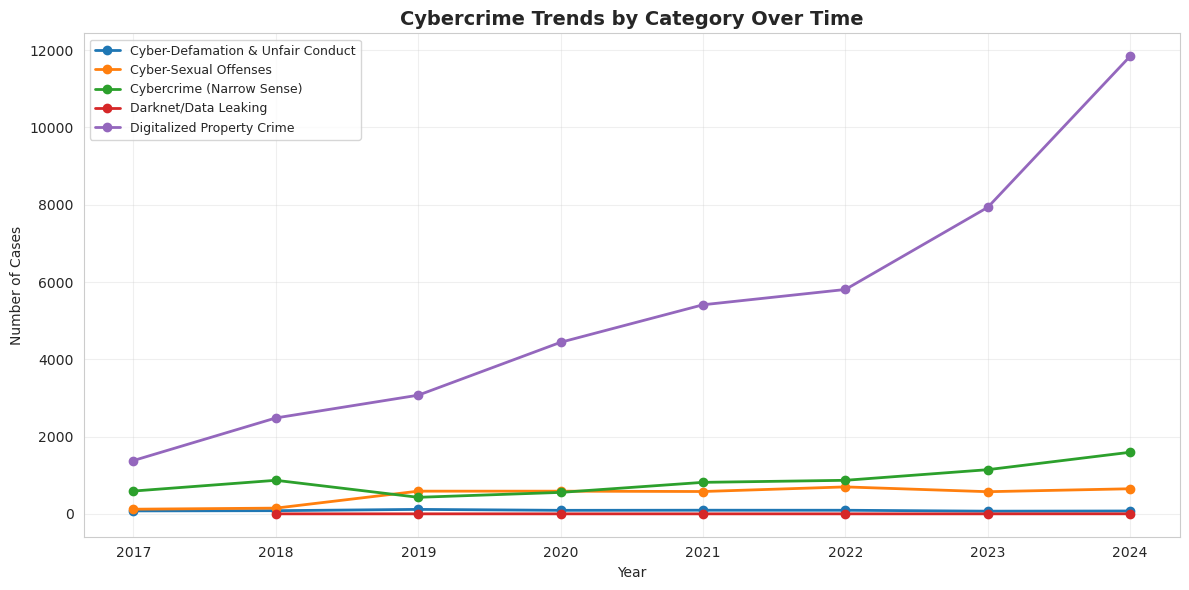

In [13]:
# Trend analysis for each category
category_trends = df.pivot_table(values='Total_Offenses', index='Year', columns='Crime_Category', aggfunc='sum')

print("\nCategory Trends Over Time:")
print(category_trends)

# Visualization
plt.figure(figsize=(12, 6))
for column in category_trends.columns:
    plt.plot(category_trends.index, category_trends[column], marker='o', label=column, linewidth=2)

plt.title('Cybercrime Trends by Category Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Average Crime Rate (per 100,000 inhabitants) by Year:
Year
2017    0.166667
2018    0.208333
2019    0.241667
2020    0.308333
2021    0.366667
2022    0.391667
2023    0.508333
2024    0.733333
Name: Crime_Rate, dtype: float64


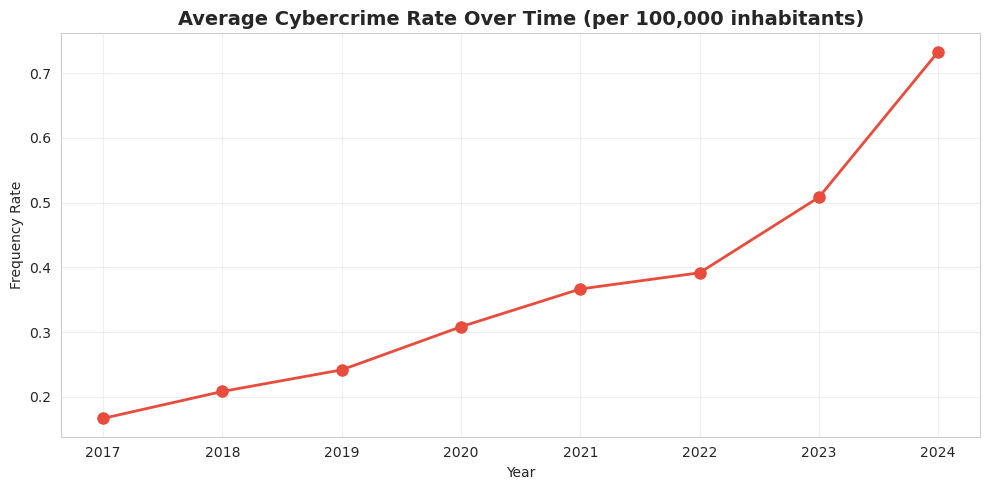

In [14]:
# Crime rate (Häufigkeitszahl) analysis
crime_rate_by_year = df.groupby('Year')['Crime_Rate'].mean()

print("\nAverage Crime Rate (per 100,000 inhabitants) by Year:")
print(crime_rate_by_year)

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(crime_rate_by_year.index, crime_rate_by_year.values, marker='o', color='#e74c3c', linewidth=2, markersize=8)
plt.title('Average Cybercrime Rate Over Time (per 100,000 inhabitants)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Frequency Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Completion Rates by Crime Type (all years combined):
                             Total_Offenses  Completed_Offenses  Completion_Rate
Crime_Type                                                                      
Data leaking                              1                   1            100.0
Diebstahl Kryptowährungen               141                 140             99.3
Sexual Offenses                        3939                3859             98.0
Hacking                                2077                1968             94.8
Financial & Parcel Agents              4311                4064             94.3
Phishing                               3795                3524             92.9
Cyberbetrug (Fraud)                   36126               33524             92.8
Defamation & Unfair Conduct             694                 633             91.2
Malware                                 880                 709             80.6
DoS/DDoS                                109             

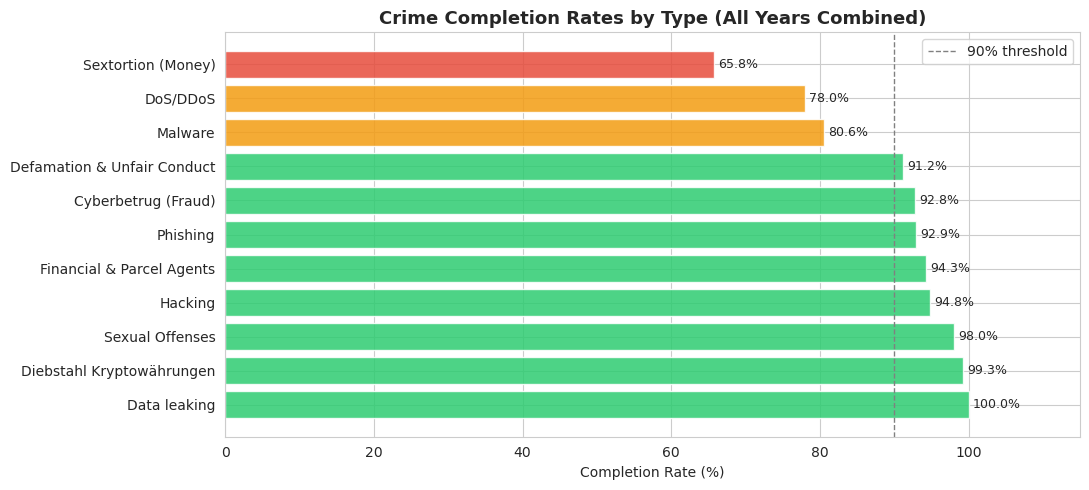

In [15]:
# Completion rate by crime type across all years (avoid single-year bias)
all_data = df.groupby('Crime_Type')[['Total_Offenses', 'Completed_Offenses']].sum()
all_data = all_data[all_data['Total_Offenses'] > 0]  # drop zero-count rows (avoids NaN / div-by-zero)
all_data['Completion_Rate'] = (all_data['Completed_Offenses'] / all_data['Total_Offenses'] * 100).round(1)
all_data = all_data.sort_values('Completion_Rate', ascending=False)

print("Completion Rates by Crime Type (all years combined):")
print(all_data.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ecc71' if r >= 90 else '#f39c12' if r >= 75 else '#e74c3c'
          for r in all_data['Completion_Rate']]
bars = ax.barh(all_data.index, all_data['Completion_Rate'], color=colors, alpha=0.85)
ax.axvline(90, color='gray', linestyle='--', linewidth=1, label='90% threshold')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlim(0, 115)
ax.set_xlabel('Completion Rate (%)')
ax.set_title('Crime Completion Rates by Type (All Years Combined)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

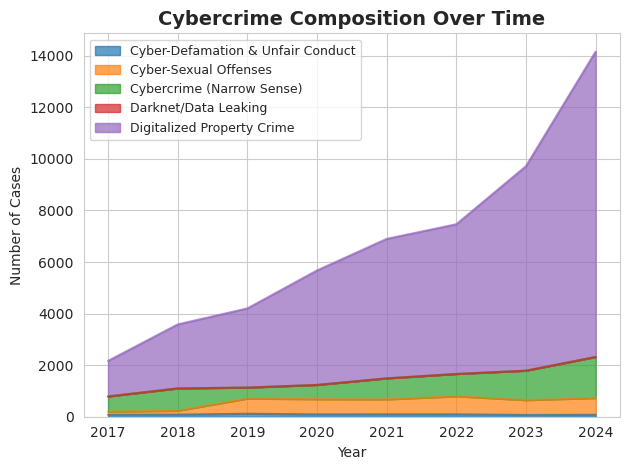

In [17]:
# Stacked area chart for category composition over time
category_composition = df.pivot_table(values='Total_Offenses', index='Year', columns='Crime_Category', aggfunc='sum')

plt.figure(figsize=(12, 6))
category_composition.plot(kind='area', stacked=True, alpha=0.7)
plt.title('Cybercrime Composition Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Year-over-Year Growth Analysis
Which crime types are growing fastest? Negative values mean the category shrank that year.


Year-over-Year Growth (%) by Category:
Crime_Category  Cyber-Defamation & Unfair Conduct  Cyber-Sexual Offenses  Cybercrime (Narrow Sense)  Darknet/Data Leaking  Digitalized Property Crime
Year                                                                                                                                                 
2017                                          NaN                    NaN                        NaN                   NaN                         NaN
2018                                          7.9                   23.3                       47.1                   NaN                        79.9
2019                                         40.2                  296.6                      -50.7                   NaN                        23.7
2020                                        -20.9                    0.0                       29.7                   NaN                        44.6
2021                                          3.3            

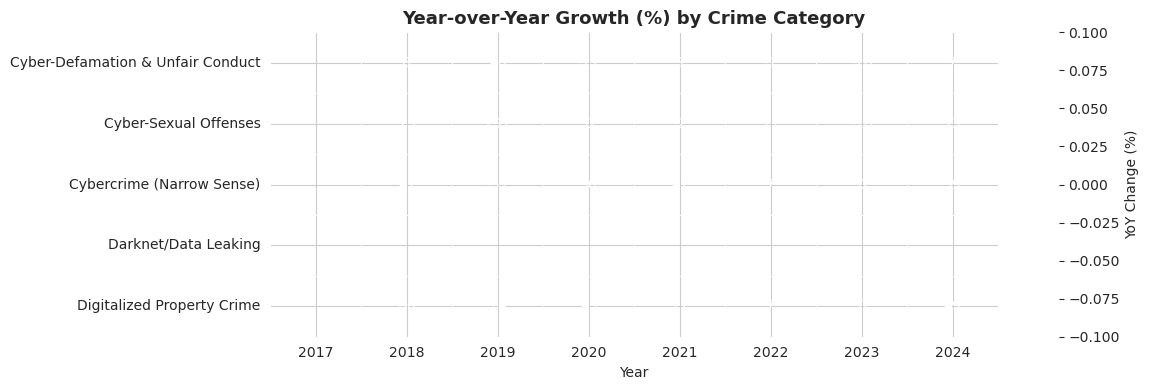

In [18]:
# Year-over-Year percentage change per crime category
yoy = df.pivot_table(values='Total_Offenses', index='Year', columns='Crime_Category', aggfunc='sum')
yoy_pct = yoy.pct_change() * 100

print("Year-over-Year Growth (%) by Category:")
print(yoy_pct.round(1).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(12, 4))
mask = yoy_pct.isna()
sns.heatmap(yoy_pct.T, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'YoY Change (%)'}, mask=mask.T)
ax.set_title('Year-over-Year Growth (%) by Crime Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## CAGR per Crime Category (2017 → 2024)
Compound annual growth rate measures the sustained pace of growth across the full period.


Compound Annual Growth Rate per Category (2017–2024):
                                   2017 Cases  2024 Cases  CAGR (%)
Crime_Category                                                     
Digitalized Property Crime             1380.0     11844.0      35.9
Cyber-Sexual Offenses                   120.0       649.0      27.3
Cybercrime (Narrow Sense)               590.0      1594.0      15.3
Cyber-Defamation & Unfair Conduct        76.0        74.0      -0.4
Darknet/Data Leaking                      NaN         1.0       NaN


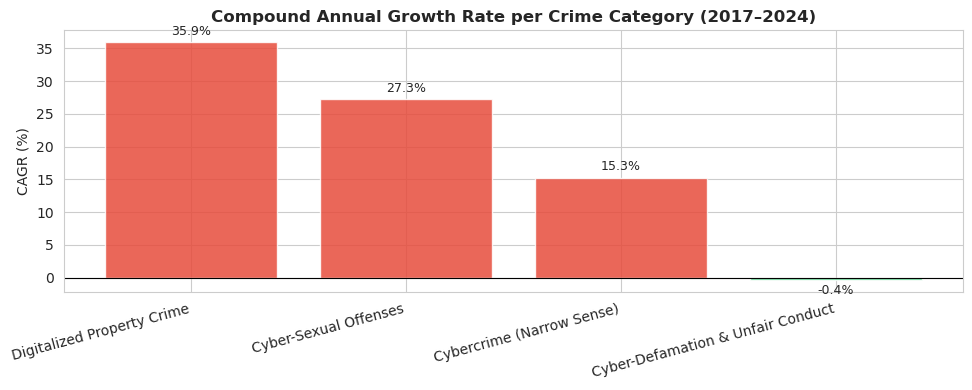

In [19]:
# CAGR = (end / start) ^ (1 / n_years) - 1
first_year, last_year = df['Year'].min(), df['Year'].max()
n_years = last_year - first_year

cat_by_year = df.pivot_table(values='Total_Offenses', index='Year', columns='Crime_Category', aggfunc='sum')
start_vals = cat_by_year.loc[first_year]
end_vals   = cat_by_year.loc[last_year]

cagr = pd.DataFrame({
    f'{first_year} Cases': start_vals,
    f'{last_year} Cases':  end_vals,
    'CAGR (%)': ((end_vals / start_vals.replace(0, np.nan)) ** (1 / n_years) - 1) * 100
}).sort_values('CAGR (%)', ascending=False)

print(f"Compound Annual Growth Rate per Category ({first_year}–{last_year}):")
print(cagr.round(1).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in cagr['CAGR (%)']]
bars = ax.bar(cagr.index, cagr['CAGR (%)'], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_ylabel('CAGR (%)')
ax.set_title(f'Compound Annual Growth Rate per Crime Category ({first_year}–{last_year})',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(cagr.index, rotation=15, ha='right')
plt.tight_layout()
plt.show()


## Attempt Rate Trend
Are criminals becoming bolder or more deterred over time? The attempt rate = attempted / total cases.


Attempt Rate (%) by Year:
      Total_Offenses  Attempted_Offenses  Attempt_Rate_%
Year                                                    
2017            2166                 269           12.42
2018            3580                 492           13.74
2019            4201                 443           10.55
2020            5673                 519            9.15
2021            6898                 634            9.19
2022            7465                 575            7.70
2023            9718                 555            5.71
2024           14162                 692            4.89


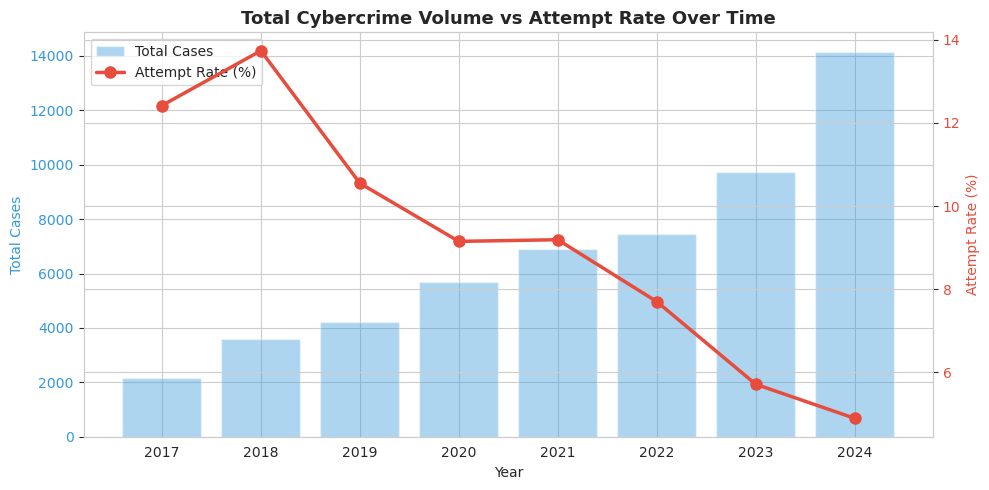

In [20]:
# Attempt rate = Attempted / Total per year
attempt_trend = df.groupby('Year')[['Total_Offenses', 'Attempted_Offenses']].sum()
attempt_trend['Attempt_Rate_%'] = (attempt_trend['Attempted_Offenses'] /
                                    attempt_trend['Total_Offenses'] * 100).round(2)

print("Attempt Rate (%) by Year:")
print(attempt_trend.to_string())

fig, ax1 = plt.subplots(figsize=(10, 5))
color_total = '#3498db'
color_rate  = '#e74c3c'

ax1.bar(attempt_trend.index, attempt_trend['Total_Offenses'], color=color_total, alpha=0.4, label='Total Cases')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Cases', color=color_total)
ax1.tick_params(axis='y', labelcolor=color_total)

ax2 = ax1.twinx()
ax2.plot(attempt_trend.index, attempt_trend['Attempt_Rate_%'], marker='o',
         color=color_rate, linewidth=2.5, markersize=8, label='Attempt Rate (%)')
ax2.set_ylabel('Attempt Rate (%)', color=color_rate)
ax2.tick_params(axis='y', labelcolor=color_rate)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Total Cybercrime Volume vs Attempt Rate Over Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Crime Type × Year Heatmap
Absolute counts per crime type across all years — shows which types dominate and when spikes occurred.


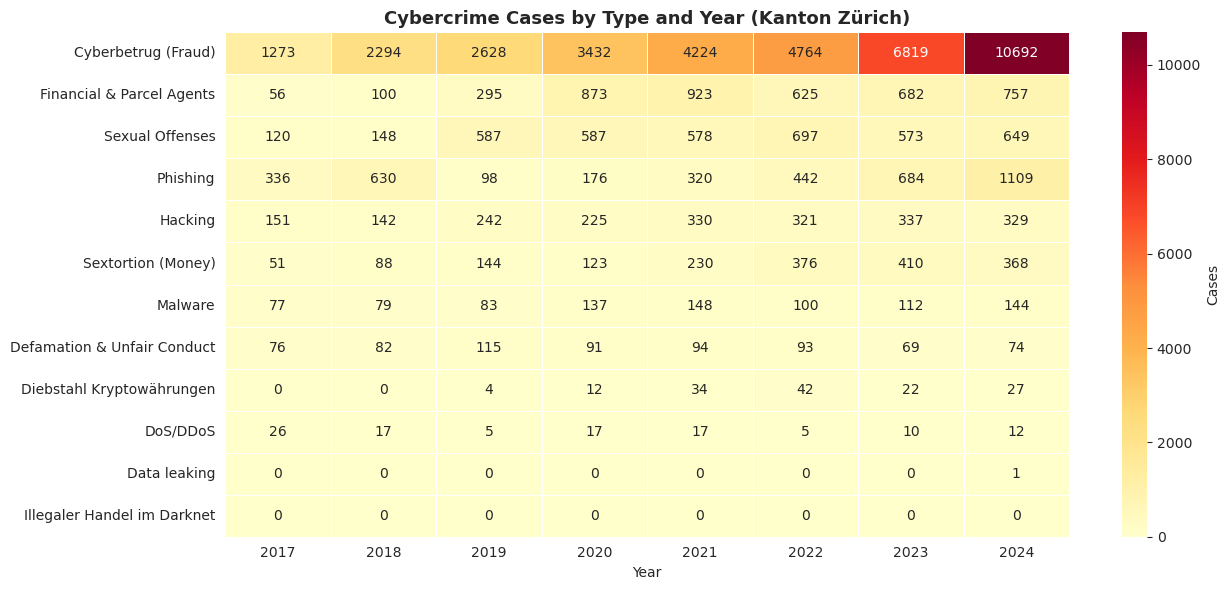

In [21]:
# Heatmap: crime type (rows) × year (columns)
heatmap_data = df.pivot_table(values='Total_Offenses', index='Crime_Type', columns='Year', aggfunc='sum').fillna(0)
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Cases'})
ax.set_title('Cybercrime Cases by Type and Year (Kanton Zürich)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## Normalized 100% Stacked Area (Category Share)
Shows how the *composition* of cybercrime shifts over time, independent of volume growth.


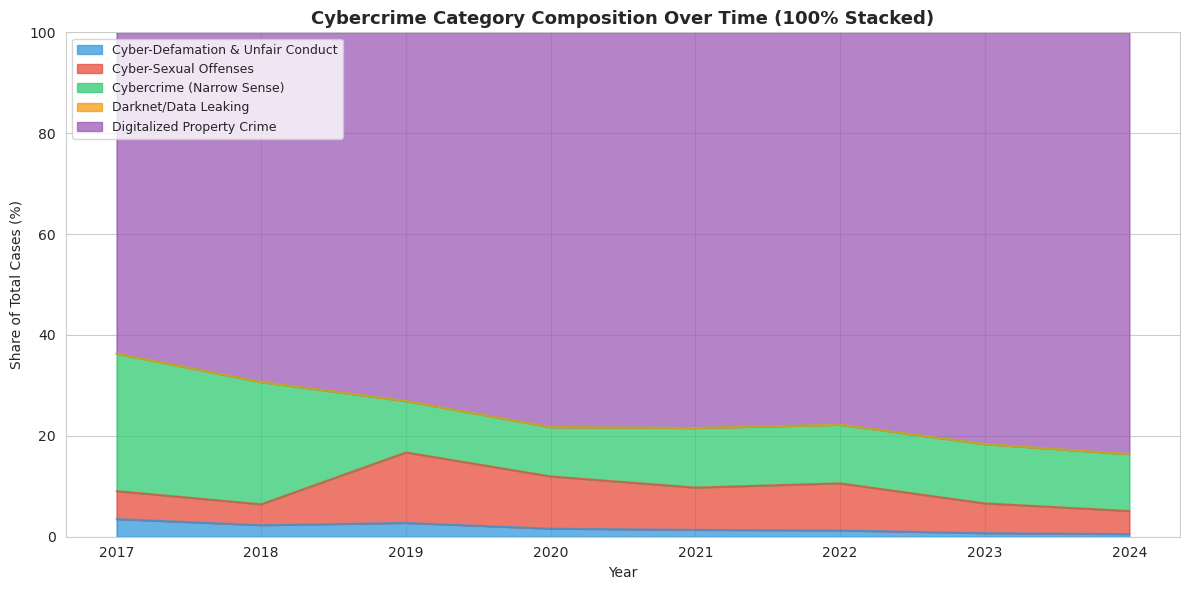

In [22]:
# Percentage share of each category per year
cat_comp = df.pivot_table(values='Total_Offenses', index='Year', columns='Crime_Category', aggfunc='sum').fillna(0)
cat_pct = cat_comp.div(cat_comp.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
cat_pct.plot(kind='area', stacked=True, alpha=0.75, ax=ax,
             color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
ax.set_ylim(0, 100)
ax.set_ylabel('Share of Total Cases (%)')
ax.set_xlabel('Year')
ax.set_title('Cybercrime Category Composition Over Time (100% Stacked)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


---
## Fancy Visualizations

Five advanced charts that reveal patterns not visible in the basic analysis above.


### 1. Bump Chart — Crime Type Rankings Over Time

Which crime types climbed or fell in the rankings? Each line traces a type's annual rank (1 = most cases).


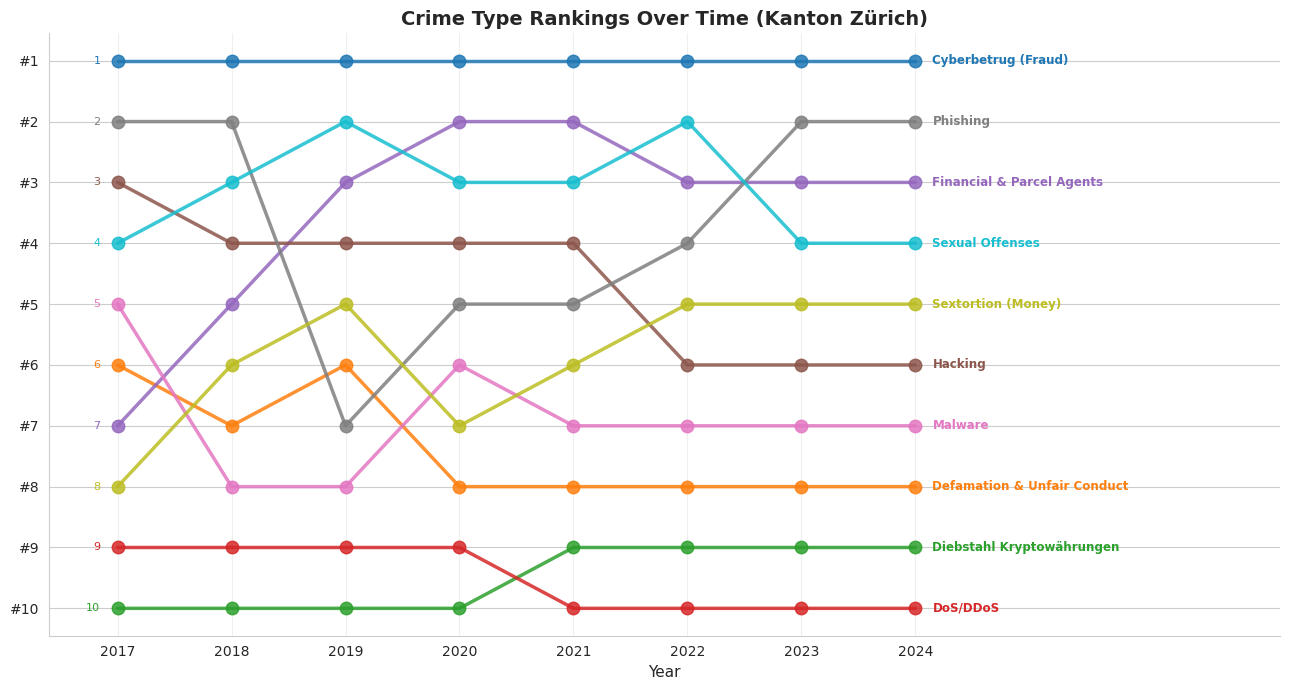

In [23]:
# Bump chart: rank of each crime type by year
pivot = df.pivot_table('Total_Offenses', 'Crime_Type', 'Year', aggfunc='sum').fillna(0)
# Exclude zero-sum types
pivot = pivot.loc[pivot.sum(axis=1) > 5]
# Rank per year (1 = highest)
ranks = pivot.rank(ascending=False, method='min').astype(int)

fig, ax = plt.subplots(figsize=(13, 7))
years = sorted(pivot.columns)

# Color palette — one per crime type
palette = plt.cm.tab10(np.linspace(0, 1, len(ranks)))

for i, (crime_type, row) in enumerate(ranks.iterrows()):
    color = palette[i]
    r = [row[y] for y in years]
    ax.plot(years, r, marker='o', linewidth=2.5, markersize=9, color=color,
            label=crime_type, alpha=0.85, zorder=3)
    # Label on right side
    ax.text(years[-1] + 0.15, r[-1], crime_type, va='center', fontsize=8.5,
            color=color, fontweight='bold')
    # Label on left side
    ax.text(years[0] - 0.15, r[0], str(r[0]), va='center', ha='right',
            fontsize=8, color=color)

ax.set_xticks(years)
ax.set_yticks(range(1, len(ranks) + 1))
ax.set_yticklabels([f'#{i}' for i in range(1, len(ranks) + 1)])
ax.invert_yaxis()  # rank 1 at top
ax.set_xlim(years[0] - 0.6, years[-1] + 3.2)
ax.set_xlabel('Year', fontsize=11)
ax.set_title('Crime Type Rankings Over Time (Kanton Zürich)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()


### 2. Radar Chart — Crime Type Profile (2017 vs 2024)

Each axis is a crime type, scaled to its 2024 maximum. The filled areas show how the overall threat profile shifted.


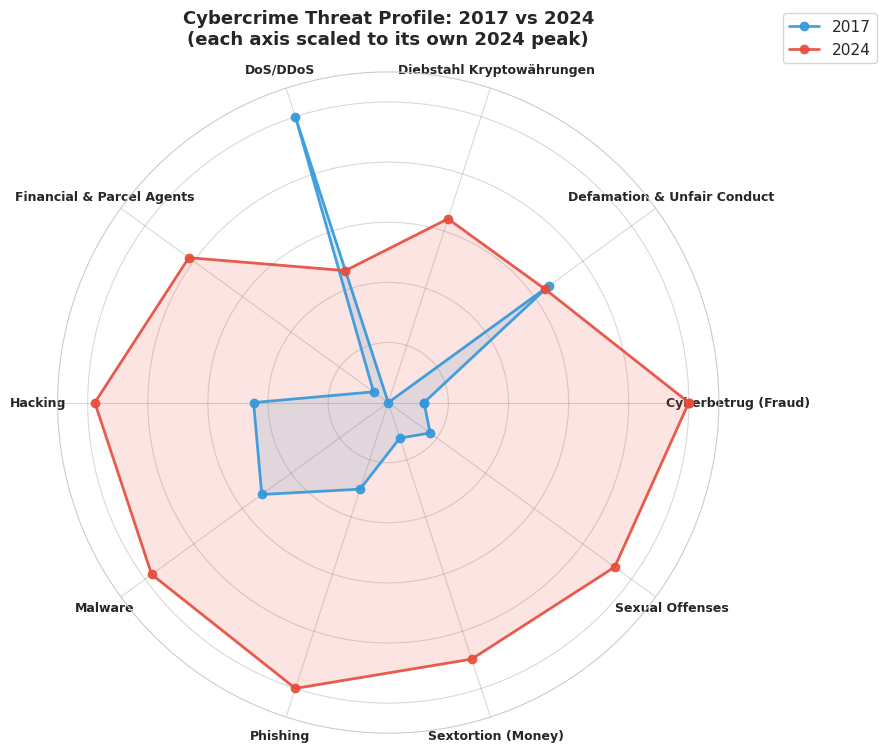

In [24]:
# Radar chart comparing 2017 vs 2024 crime type profile
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

pivot = df.pivot_table('Total_Offenses', 'Crime_Type', 'Year', aggfunc='sum').fillna(0)
# Keep types present in both years and with meaningful volume
keep = pivot.loc[(pivot[2017] > 0) | (pivot[2024] > 5)].index
pivot = pivot.loc[keep]

types = list(pivot.index)
N = len(types)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

def to_radar(values, max_vals):
    normed = [v / m if m > 0 else 0 for v, m in zip(values, max_vals)]
    return normed + normed[:1]

max_vals = pivot.max(axis=1).values
vals_2017 = to_radar(pivot[2017].values, max_vals)
vals_2024 = to_radar(pivot[2024].values, max_vals)

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

ax.plot(angles, vals_2017, 'o-', linewidth=2, color='#3498db', alpha=0.9, label='2017')
ax.fill(angles, vals_2017, alpha=0.15, color='#3498db')
ax.plot(angles, vals_2024, 'o-', linewidth=2, color='#e74c3c', alpha=0.9, label='2024')
ax.fill(angles, vals_2024, alpha=0.15, color='#e74c3c')

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(types, size=9, fontweight='bold')
ax.set_yticklabels([])
ax.set_ylim(0, 1.1)
ax.set_title('Cybercrime Threat Profile: 2017 vs 2024\n(each axis scaled to its own 2024 peak)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=11)
ax.grid(color='gray', alpha=0.3)
plt.tight_layout()
plt.show()


### 3. Slope Graph — Cases per 100,000 Population (2017 → 2024)

Population-adjusted view. Steep upward slopes = genuine growth, not just more people.


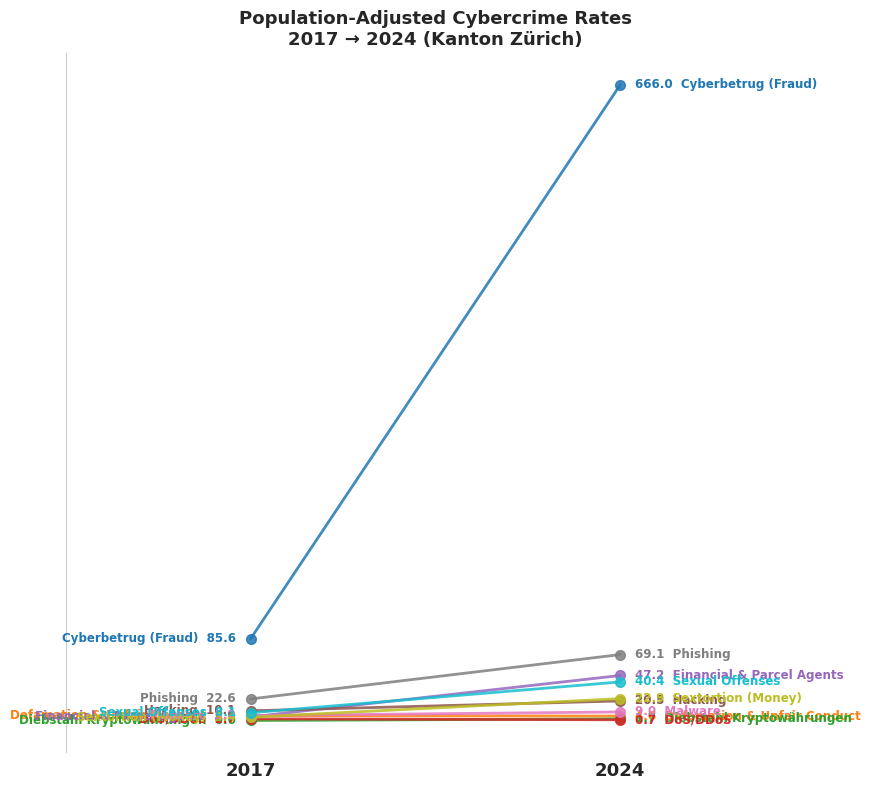

In [25]:
# Slope graph: cases per 100k, 2017 vs 2024
pop = df.groupby('Year')['Population'].first()
per100k = df.pivot_table('Total_Offenses','Crime_Type','Year',aggfunc='sum').fillna(0)
per100k = per100k.div(pop / 100000)

# Filter to types with meaningful volume
keep = per100k.loc[(per100k[2017] >= 1) | (per100k[2024] >= 1)].index
per100k = per100k.loc[keep]

fig, ax = plt.subplots(figsize=(9, 8))
palette = plt.cm.tab10(np.linspace(0, 1, len(per100k)))

for i, (ct, row) in enumerate(per100k.iterrows()):
    v17, v24 = row[2017], row[2024]
    color = palette[i]
    ax.plot([0, 1], [v17, v24], marker='o', markersize=7, linewidth=2,
            color=color, alpha=0.85)
    ax.text(-0.04, v17, f'{ct}  {v17:.1f}', ha='right', va='center',
            fontsize=8.5, color=color, fontweight='bold')
    ax.text(1.04, v24, f'{v24:.1f}  {ct}', ha='left', va='center',
            fontsize=8.5, color=color, fontweight='bold')

ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['2017', '2024'], fontsize=13, fontweight='bold')
ax.set_ylabel('Cases per 100,000 population')
ax.set_title('Population-Adjusted Cybercrime Rates\n2017 → 2024 (Kanton Zürich)',
             fontsize=13, fontweight='bold')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.yaxis.set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()


### 4. Streamgraph — Crime Type Volume Over Time

A streamgraph centers the stacked areas around zero, creating a flowing organic shape that highlights volume surges.


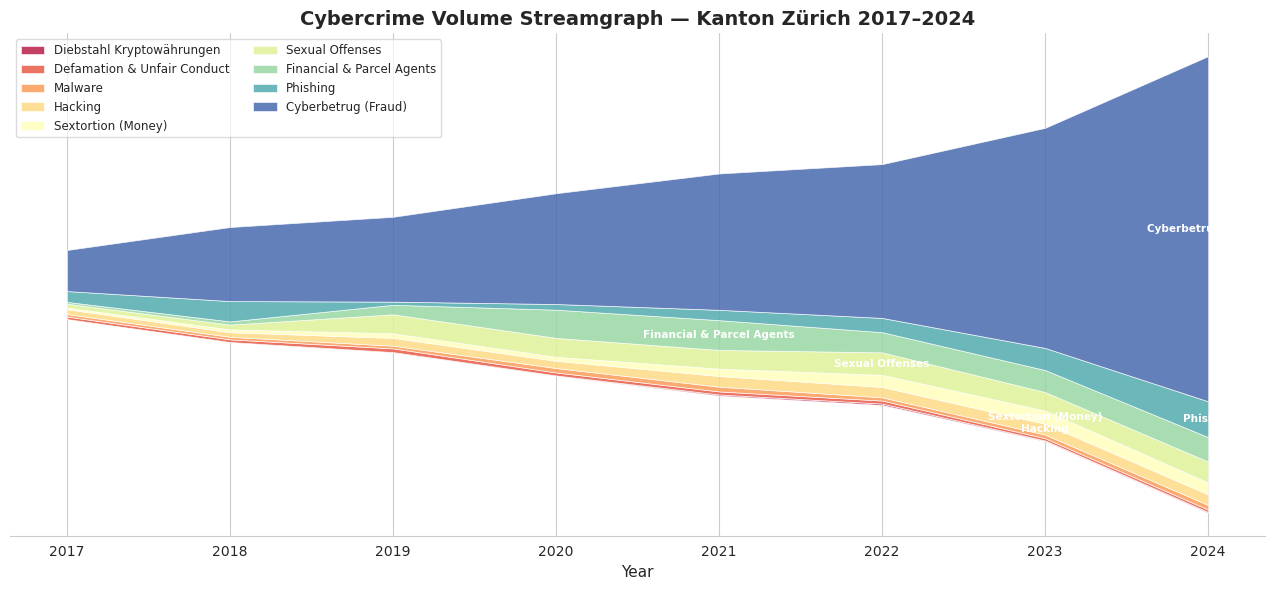

In [26]:
# Streamgraph (wiggle baseline) of crime types over time
from matplotlib.collections import PolyCollection

stream_data = df.pivot_table('Total_Offenses','Crime_Type','Year',aggfunc='sum').fillna(0)
# Drop near-zero series for clarity
stream_data = stream_data.loc[stream_data.max(axis=1) >= 30]
stream_data = stream_data.sort_values(stream_data.columns[-1])  # order by 2024 value

years = np.array(sorted(stream_data.columns))
matrix = stream_data.values  # shape: (n_types, n_years)

# Wiggle baseline (silhouette / streamgraph centering)
n = matrix.shape[0]
baseline = -0.5 * matrix.sum(axis=0)

fig, ax = plt.subplots(figsize=(13, 6))
palette = plt.cm.Spectral(np.linspace(0.05, 0.95, n))

bottom = baseline.copy()
handles = []
for i in range(n):
    top = bottom + matrix[i]
    ax.fill_between(years, bottom, top, alpha=0.85, color=palette[i], linewidth=0.5,
                    edgecolor='white', label=stream_data.index[i])
    # Place label at peak
    peak_idx = np.argmax(matrix[i])
    mid = (bottom[peak_idx] + top[peak_idx]) / 2
    if matrix[i].max() > 200:
        ax.text(years[peak_idx], mid, stream_data.index[i], ha='center',
                va='center', fontsize=7.5, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.1', fc='none', ec='none'))
    bottom = top

ax.set_xticks(years)
ax.set_xticklabels(years)
ax.set_yticks([])
ax.set_xlabel('Year', fontsize=11)
ax.set_title('Cybercrime Volume Streamgraph — Kanton Zürich 2017–2024',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=8.5, ncol=2, framealpha=0.7)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()


### 5. Bubble Chart — Volume × Growth × Completion Rate

Three dimensions at once: x = 2024 case volume, y = CAGR 2017→2024, bubble size = completion rate.  
Top-right = high-volume fast-growing crimes. Large bubbles = hard to stop.


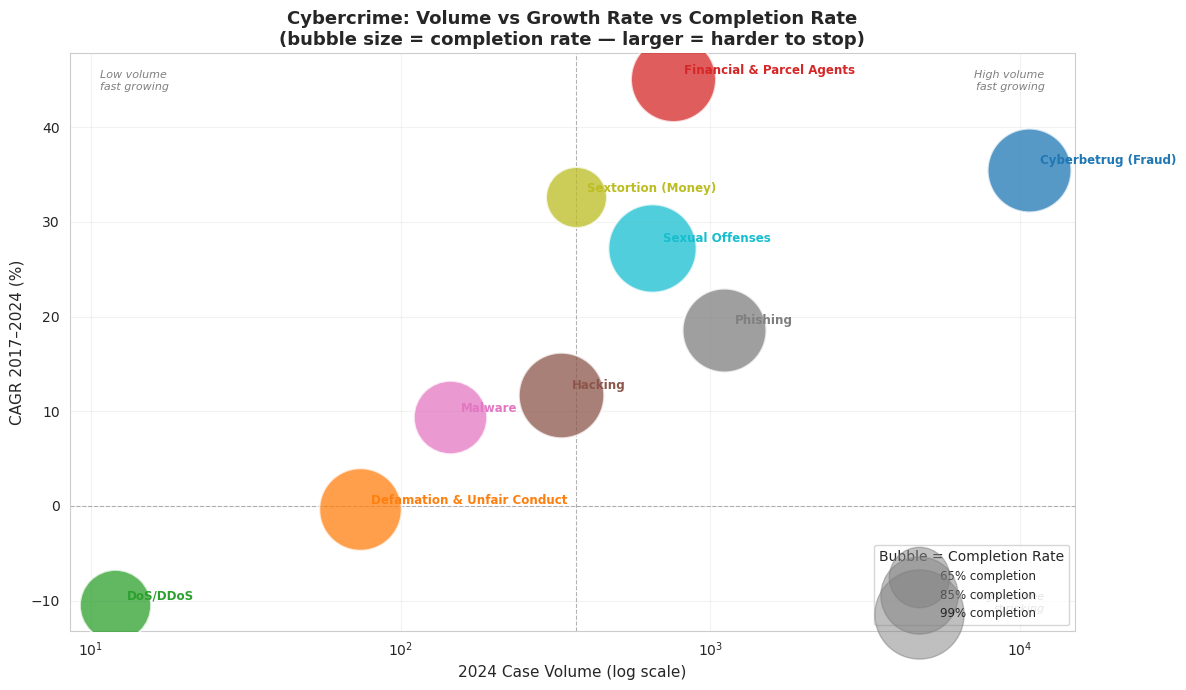

In [27]:
# Bubble chart: x=2024 volume, y=CAGR, size=completion rate
pivot = df.pivot_table('Total_Offenses','Crime_Type','Year',aggfunc='sum').fillna(0)
pivot = pivot.loc[pivot.sum(axis=1) > 5]

first_yr, last_yr = df['Year'].min(), df['Year'].max()
n_yrs = last_yr - first_yr

completion = df.groupby('Crime_Type')[['Total_Offenses','Completed_Offenses']].sum()
completion = completion[completion['Total_Offenses'] > 0]
completion['rate'] = (completion['Completed_Offenses'] / completion['Total_Offenses'] * 100)

rows = []
for ct in pivot.index:
    v0 = pivot.loc[ct, first_yr]
    v1 = pivot.loc[ct, last_yr]
    if v0 > 0 and v1 > 0:
        cagr = ((v1 / v0) ** (1 / n_yrs) - 1) * 100
    else:
        cagr = np.nan
    comp_rate = completion.loc[ct, 'rate'] if ct in completion.index else np.nan
    rows.append({'type': ct, 'volume_2024': v1, 'cagr': cagr, 'completion': comp_rate})

bdf = pd.DataFrame(rows).dropna().reset_index(drop=True)  # reset so palette[i] is in-bounds

fig, ax = plt.subplots(figsize=(12, 7))
palette = plt.cm.tab10(np.linspace(0, 1, len(bdf)))

for i, row in bdf.iterrows():
    size = (row['completion'] / 100) ** 2 * 4000 + 200
    ax.scatter(row['volume_2024'], row['cagr'], s=size, color=palette[i],
               alpha=0.75, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(row['type'], (row['volume_2024'], row['cagr']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=8.5, fontweight='bold', color=palette[i])

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(bdf['volume_2024'].median(), color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('2024 Case Volume (log scale)', fontsize=11)
ax.set_ylabel('CAGR 2017–2024 (%)', fontsize=11)
ax.set_title('Cybercrime: Volume vs Growth Rate vs Completion Rate\n'
             '(bubble size = completion rate — larger = harder to stop)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.25)

# Quadrant labels
ax.text(0.97, 0.97, 'High volume\nfast growing', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='gray', style='italic')
ax.text(0.03, 0.97, 'Low volume\nfast growing', transform=ax.transAxes,
        ha='left', va='top', fontsize=8, color='gray', style='italic')
ax.text(0.97, 0.03, 'High volume\nshrinking', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=8, color='gray', style='italic')

# Legend for bubble size
for comp_pct, label in [(65, '65%'), (85, '85%'), (99, '99%')]:
    s = (comp_pct / 100) ** 2 * 4000 + 200
    ax.scatter([], [], s=s, color='gray', alpha=0.5, label=f'{label} completion')
ax.legend(title='Bubble = Completion Rate', loc='lower right', fontsize=8.5)

plt.tight_layout()
plt.show()


## Summary of Interesting Visualization Ideas

Based on the data analysis above, here are **compelling visualizations** for displaying the Swiss cybercrime situation:

### 1. **Time Series Line Chart (Overall Trend)**
- Show total cybercrime cases over years
- Simple, clear trend showing growth or decline
- Good for the main homepage/landing page

### 2. **Category Breakdown (Horizontal Bar Chart)**
- Display the 4-5 main crime categories with total cases
- Color-coded by category type
- Shows which categories are most prevalent

### 3. **Multi-Line Trend Analysis**
- Show how each major crime category trends over time
- Reveals which types are increasing/decreasing
- Good for understanding shifts in cybercrime patterns

### 4. **Stacked Area Chart**
- Shows both total volume AND category composition changes
- Visually shows how the cybercrime landscape is evolving
- Useful for understanding market share of each crime type

### 5. **Completed vs Attempted Comparison**
- Stacked or grouped bar chart by year
- Shows success rate and deterrence effectiveness
- Indicates which years had more attempted vs completed crimes

### 6. **Crime Type Ranking (Top 10)**
- Horizontal bar chart of the most common specific crime types
- Examples: Cyberbetrug (fraud), Phishing, Hacking, etc.
- Helps identify the most pressing threats

### 7. **Crime Rate Heatmap**
- Matrix showing category × year with color intensity
- Easy to spot trends and peaks
- Good for detailed exploration

### 8. **Interactive Dashboard (Future)**
- Combine multiple views (filters, drill-downs)
- Allow users to explore by category, year, crime type
- Show completion rates and frequency statistics